# Market structure: sparse covariance + affinity-propagation clustering
**Problem:** Find groups of assets that move together without choosing the number of clusters in advance.
**Approach:** Use daily open→close variations over the last 50 sessions. `GraphicalLassoCV` estimates a sparse inverse covariance, affinity propagation clusters on it, and a 2-D embedding shows the links between assets.
**Data:** Public Yahoo Finance data for currencies, indices, commodities, volatility, yields and crypto.
**Attribution:** adapted from the scikit-learn gallery example *"Visualizing the stock market structure"* (BSD-3-Clause), applied here to a custom multi-asset symbol list.

In [1]:
%matplotlib inline

import sys

import yfinance as yf

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

import pandas as pd

from sklearn import cluster, covariance, manifold

In [2]:
symbol_dict = {
    'CADUSD=X' : 'CAD/USD',
    'CADEUR=X' : 'CAD/EUR',
    '^VIX' : 'Volatility Index',
    '^GSPC': 'S&P 500',
    '^GSPTSE': 'S&P/TSX',
    'BTC-CAD' : 'BTC-CAD',
    'GC=F' : 'Gold Futures',
    '^TNX' : 'Treasury Yield 10 Years',
    'CL=F' : 'Crude Oil',
    '^DJI' : 'DOW',
    '^IXIC' : 'NASDAQ composite',
    '^CMC200' : 'CMC Crypto 200',
    
}


symbols, names = np.array(sorted(symbol_dict.items())).T

quotes = []

for symbol in symbols:
    print('Fetching quote history for %r' % symbol, file=sys.stderr)
    ticker = symbol
    stock = yf.Ticker(ticker)
    stockHistory = stock.history(period="3mo")
    quotes.append(stockHistory)

In [3]:
# Align all assets on common calendar dates (crypto trades weekends, FX/indices don't)
# and skip symbols that returned no data, then keep the last 51 common sessions.
def by_date(q, col):
    s = q[col].copy()
    s.index = pd.Index(q.index.date, name='date')
    return s

valid = np.array([not q.empty for q in quotes])
if (~valid).any():
    print('Skipping (no data returned):', ', '.join(symbols[~valid]))
symbols, names = symbols[valid], names[valid]
quotes = [q for q, ok in zip(quotes, valid) if ok]

closes = pd.concat([by_date(q, 'Close') for q in quotes], axis=1, keys=symbols).dropna()
opens = pd.concat([by_date(q, 'Open') for q in quotes], axis=1, keys=symbols).dropna()
common = closes.index.intersection(opens.index)[-51:]
close_prices = closes.loc[common].T.to_numpy()
open_prices = opens.loc[common].T.to_numpy()
print(f'{len(symbols)} assets x {len(common)} common sessions')

Skipping (no data returned): ^CMC200
11 assets x 51 common sessions


In [4]:
variation = close_prices - open_prices

In [5]:
edge_model = covariance.GraphicalLassoCV()

In [6]:
X = variation.copy().T
X /= X.std(axis=0)
edge_model.fit(X)

GraphicalLassoCV()

Cluster 1: CAD/USD, Crude Oil, Treasury Yield 10 Years, Volatility Index
Cluster 2: BTC-CAD, CAD/EUR, Gold Futures
Cluster 3: DOW, S&P 500, S&P/TSX, NASDAQ composite


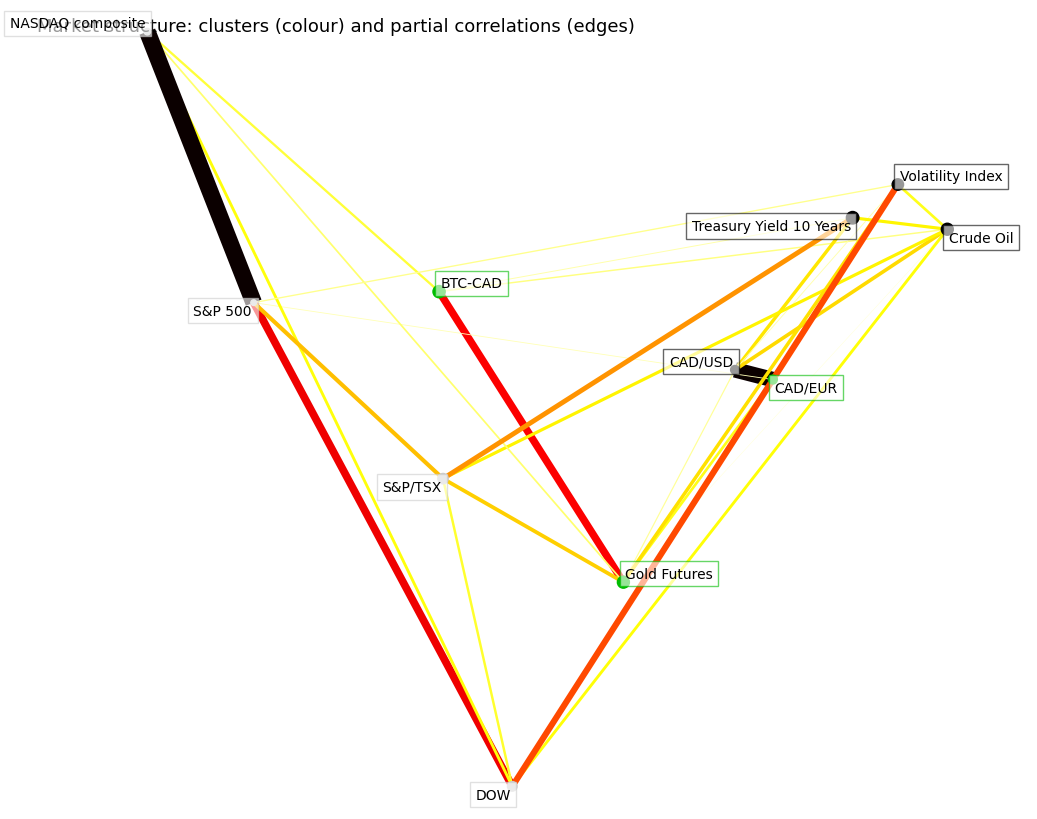

In [7]:
_, labels = cluster.affinity_propagation(edge_model.covariance_)
n_labels = labels.max()

for i in range(n_labels + 1):
    print('Cluster %i: %s' % ((i + 1), ', '.join(names[labels == i])))

# #############################################################################
# Find a low-dimension embedding for visualization: find the best position of
# the nodes (the stocks) on a 2D plane

# We use a dense eigen_solver to achieve reproducibility (arpack is
# initiated with random vectors that we don't control). In addition, we
# use a large number of neighbors to capture the large-scale structure.
node_position_model = manifold.LocallyLinearEmbedding(
    n_components=2, eigen_solver='dense', n_neighbors=6)

embedding = node_position_model.fit_transform(X.T).T

# #############################################################################
# Visualization
plt.figure(1, facecolor='w', figsize=(10, 8))
plt.clf()
ax = plt.axes([0., 0., 1., 1.])
plt.axis('off')
ax.text(0.01, 0.99, 'Market structure: clusters (colour) and partial correlations (edges)',
        transform=ax.transAxes, fontsize=13, va='top')

# Display a graph of the partial correlations
partial_correlations = edge_model.precision_.copy()
d = 1 / np.sqrt(np.diag(partial_correlations))
partial_correlations *= d
partial_correlations *= d[:, np.newaxis]
non_zero = (np.abs(np.triu(partial_correlations, k=1)) > 0.02)

# Plot the nodes using the coordinates of our embedding
plt.scatter(embedding[0], embedding[1], s=100 * d ** 2, c=labels,
            cmap=plt.cm.nipy_spectral)

# Plot the edges
start_idx, end_idx = np.where(non_zero)
# a sequence of (*line0*, *line1*, *line2*), where::
#            linen = (x0, y0), (x1, y1), ... (xm, ym)
segments = [[embedding[:, start], embedding[:, stop]]
            for start, stop in zip(start_idx, end_idx)]
values = np.abs(partial_correlations[non_zero])
lc = LineCollection(segments,
                    zorder=0, cmap=plt.cm.hot_r,
                    norm=plt.Normalize(0, .7 * values.max()))
lc.set_array(values)
lc.set_linewidths(15 * values)
ax.add_collection(lc)

# Add a label to each node. The challenge here is that we want to
# position the labels to avoid overlap with other labels
for index, (name, label, (x, y)) in enumerate(
        zip(names, labels, embedding.T)):

    dx = x - embedding[0]
    dx[index] = 1
    dy = y - embedding[1]
    dy[index] = 1
    this_dx = dx[np.argmin(np.abs(dy))]
    this_dy = dy[np.argmin(np.abs(dx))]
    if this_dx > 0:
        horizontalalignment = 'left'
        x = x + .002
    else:
        horizontalalignment = 'right'
        x = x - .002
    if this_dy > 0:
        verticalalignment = 'bottom'
        y = y + .002
    else:
        verticalalignment = 'top'
        y = y - .002
    plt.text(x, y, name, size=10,
             horizontalalignment=horizontalalignment,
             verticalalignment=verticalalignment,
             bbox=dict(facecolor='w',
                       edgecolor=plt.cm.nipy_spectral(label / float(n_labels)),
                       alpha=.6))

plt.xlim(embedding[0].min() - .15 * np.ptp(embedding[0]),
         embedding[0].max() + .10 * np.ptp(embedding[0]),)
plt.ylim(embedding[1].min() - .03 * np.ptp(embedding[1]),
         embedding[1].max() + .03 * np.ptp(embedding[1]))

plt.show()